# Лабораторная работа 1
## Выполнил: Стрельников Никита, группа 6401-010302D
## Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере.

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

### 1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST
sklearn.datasets import load_digits
digits = load_digits()

In [7]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


### 1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



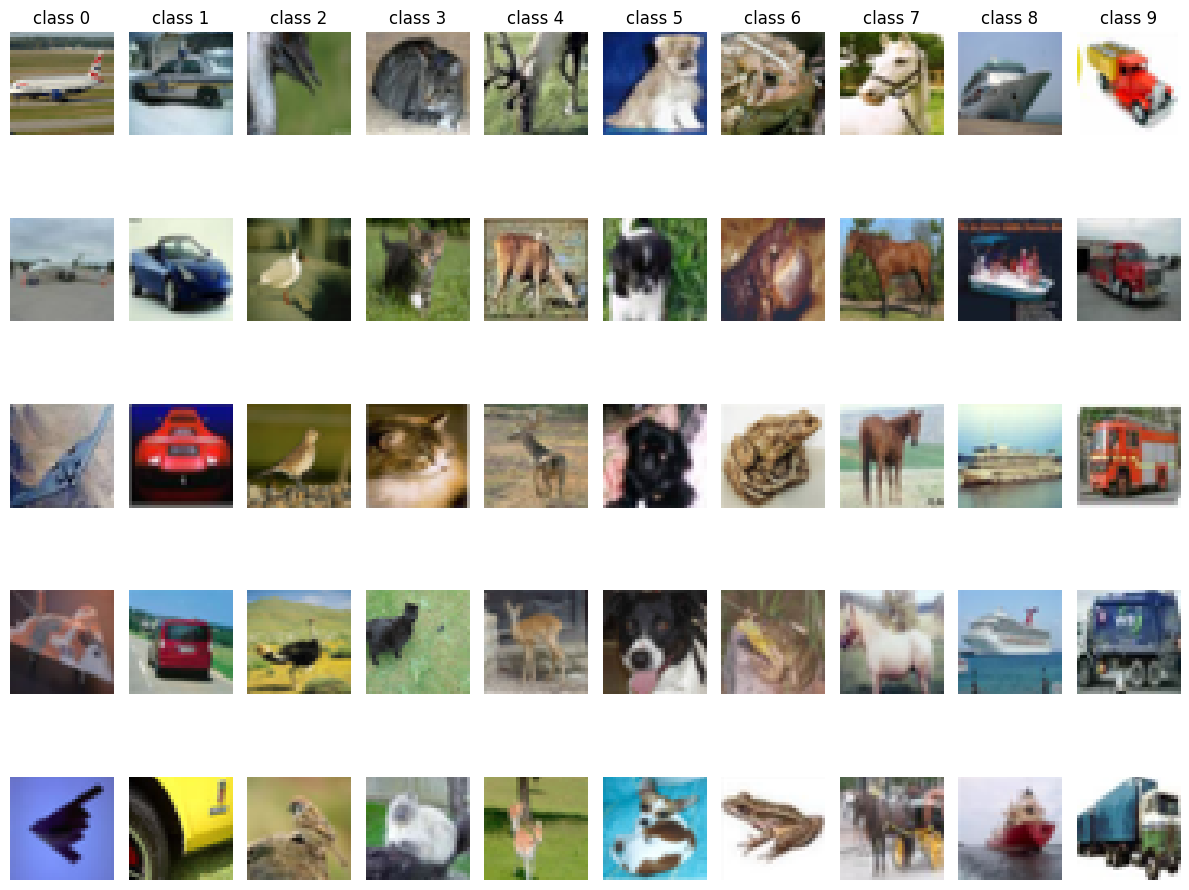

In [8]:
labels = np.unique(y_train)
samples_per_class = 5

plt.figure(figsize=(12, 10))

for y in labels:
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)

    for i, idx in enumerate(idxs):
        plt_idx = i * len(labels) + y + 1
        plt.subplot(samples_per_class, len(labels), plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')

        if i == 0:
            plt.title(f'class {y}')

plt.tight_layout()
plt.show()

### 1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив.

Т.к. данные уже разделены на тестовую и обучающую, преобразуем в одномерный массив.

In [9]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print('Train:', X_train_flat.shape)
print('Test:', X_test_flat.shape)

Train: (50000, 3072)
Test: (10000, 3072)


### 1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке.

In [11]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train_flat, y_train)

### 1.5 Выполните классификацию на тестовой выборке

Чтобы не хранить всю выборку в памяти, обрабатываем батчами.

In [12]:
def predict_in_batches(classifier, X_test, y_test, batch_size=200, k=3):
    y_pred = []
    dists_list = []
    for i in range(0, X_test.shape[0], batch_size):
        X_batch = X_test[i:i+batch_size]

        dists = classifier.compute_distances_no_loops(X_batch)
        y_batch_pred = classifier.predict_labels(dists, k=k)

        dists_list.append(dists)
        y_pred.append(y_batch_pred)
    return np.concatenate(y_pred), np.concatenate(dists_list)

In [13]:
batch_size = 200

y_test_pred, dists = predict_in_batches(classifier, X_test_flat, y_test, batch_size=batch_size, k=3)

### 1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки.


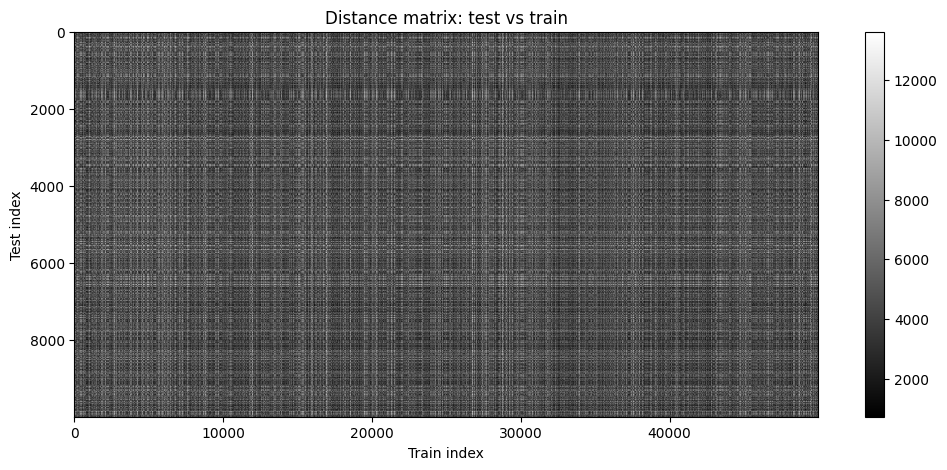

In [14]:
plt.figure(figsize=(12, 5))
plt.imshow(dists, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xlabel('Train index')
plt.ylabel('Test index')
plt.title('Distance matrix: test vs train')
plt.show()

### 1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [15]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = num_correct / len(y_test)

print('Correct:', num_correct)
print('Total:', len(y_test))
print('Accuracy:', accuracy)

Correct: 3303
Total: 10000
Accuracy: 0.3303


### 1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

Определим значения параметра k

In [16]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20]

num_train = 5000
X_train_flat = X_train_flat[:num_train]
y_train = y_train[:num_train]

X_train_folds = np.array_split(X_train_flat, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

In [17]:
k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []

    for i in range(num_folds):
        # validation fold
        X_val = X_train_folds[i]
        y_val = y_train_folds[i]

        # training folds
        X_train_cv = np.concatenate([X_train_folds[j] for j in range(num_folds) if j != i])
        y_train_cv = np.concatenate([y_train_folds[j] for j in range(num_folds) if j != i])

        classifier = KNearestNeighbor()
        classifier.train(X_train_cv, y_train_cv)

        dists = classifier.compute_distances_no_loops(X_val)
        y_val_pred = classifier.predict_labels(dists, k=k)

        acc = np.mean(y_val_pred == y_val)
        k_to_accuracies[k].append(acc)

        print(f"k={k}, fold={i}, acc={acc:.4f}")

k=1, fold=0, acc=0.2630
k=1, fold=1, acc=0.2570
k=1, fold=2, acc=0.2640
k=1, fold=3, acc=0.2780
k=1, fold=4, acc=0.2660
k=3, fold=0, acc=0.2390
k=3, fold=1, acc=0.2490
k=3, fold=2, acc=0.2400
k=3, fold=3, acc=0.2660
k=3, fold=4, acc=0.2540
k=5, fold=0, acc=0.2480
k=5, fold=1, acc=0.2660
k=5, fold=2, acc=0.2800
k=5, fold=3, acc=0.2920
k=5, fold=4, acc=0.2800
k=8, fold=0, acc=0.2620
k=8, fold=1, acc=0.2820
k=8, fold=2, acc=0.2730
k=8, fold=3, acc=0.2900
k=8, fold=4, acc=0.2730
k=10, fold=0, acc=0.2650
k=10, fold=1, acc=0.2960
k=10, fold=2, acc=0.2760
k=10, fold=3, acc=0.2840
k=10, fold=4, acc=0.2800
k=12, fold=0, acc=0.2600
k=12, fold=1, acc=0.2950
k=12, fold=2, acc=0.2790
k=12, fold=3, acc=0.2830
k=12, fold=4, acc=0.2800
k=15, fold=0, acc=0.2520
k=15, fold=1, acc=0.2890
k=15, fold=2, acc=0.2780
k=15, fold=3, acc=0.2820
k=15, fold=4, acc=0.2740
k=20, fold=0, acc=0.2700
k=20, fold=1, acc=0.2790
k=20, fold=2, acc=0.2790
k=20, fold=3, acc=0.2820
k=20, fold=4, acc=0.2850


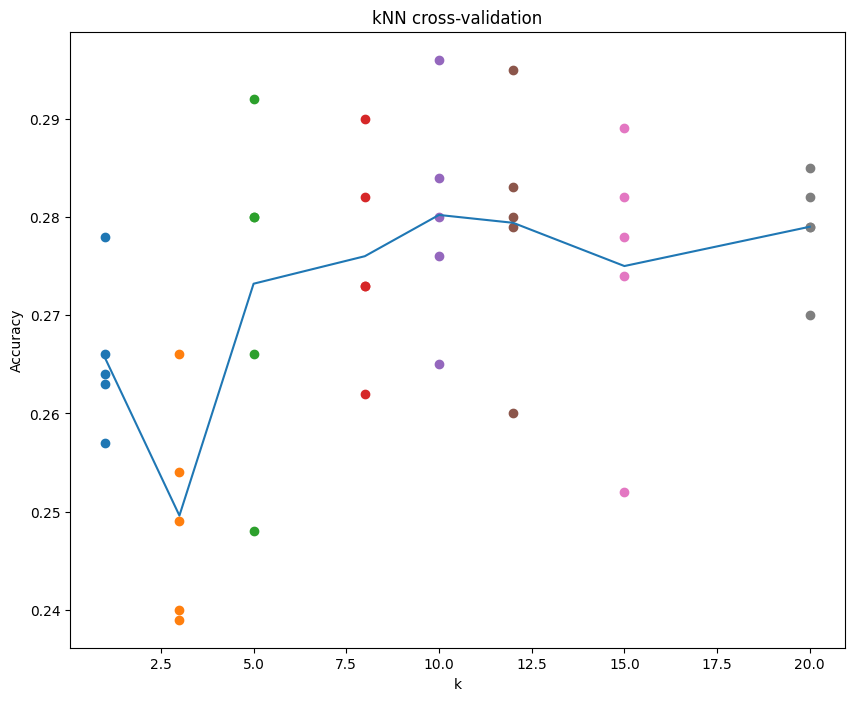

In [18]:
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k]*len(accuracies), accuracies)

mean_accuracies = [np.mean(k_to_accuracies[k]) for k in k_choices]

plt.plot(k_choices, mean_accuracies)

plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('kNN cross-validation')
plt.show()

### 1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [19]:
best_k = max(k_choices, key=lambda k: np.mean(k_to_accuracies[k]))
print("Best k:", best_k)

Best k: 10


### 1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [21]:
classifier = KNearestNeighbor()
classifier.train(X_train_flat, y_train)

y_test_pred, _ = predict_in_batches(classifier, X_test_flat, y_test, batch_size=batch_size, k=best_k)
accuracy = np.mean(y_test_pred == y_test)
print('Test accuracy:', accuracy)

Test accuracy: 0.2793


### 1.11 Сделайте выводы по результатам 1 части задания.

### Выводы
1. Алгортим kNN показал невысокую точность на датасете CIFAR-10 (в среднем 25-28%). Результат сильно уступает современным методам классификации.
2. Точность классификации слабо зависит от параметра k. Самая низкая точность - 25%, самая высокая - 28%, что указывает на несущественное влияние на выбор параметра k.
3. При использовании всей обучающей и тестовой выборок нередки случаи нехватки памяти. Это связано с тем, что матрица расстояний между объектами имеет размер (num_test * num_train). При обучении необходимо использовать подвыборки или вычислять значения батчами.

## 3.  Построение softmax-классификатора

### 3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [22]:
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

In [23]:
num_training = 49000
num_validation = 1000
num_test = 10000

# validation из начала train
X_val = X_train[:num_validation]
y_val = y_train[:num_validation]

# оставшаяся часть — train
X_train = X_train[num_validation:num_validation + num_training]
y_train = y_train[num_validation:num_validation + num_training]

# test (как есть)
X_test = X_test[:num_test]
y_test = y_test[:num_test]

In [24]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print('Train shape:', X_train.shape)
print('Train labels:', y_train.shape)

print('Val shape:', X_val.shape)
print('Val labels:', y_val.shape)

print('Test shape:', X_test.shape)
print('Test labels:', y_test.shape)

Train shape: (49000, 3072)
Train labels: (49000,)
Val shape: (1000, 3072)
Val labels: (1000,)
Test shape: (10000, 3072)
Test labels: (10000,)


### 3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

[130.6544898  136.00577551 132.51434694 130.08681633 135.38777551
 131.80189796 130.99630612 136.18583673 132.52006122 131.5157551 ]


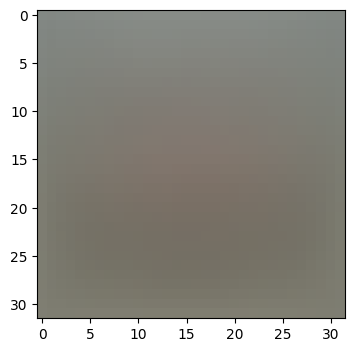

In [25]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])

plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8'))
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

### 3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

In [26]:
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape)

(49000, 3073) (1000, 3073) (10000, 3073)


### 3.4 Реализуйте функции в classifiers/softmax.py




In [27]:
import time
from scripts.classifiers.softmax import softmax_loss_naive

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_test, y_test, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.313785
sanity check: 2.302585


### 3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [28]:
from scripts.gradient_check import grad_check_sparse

loss, grad = softmax_loss_naive(W, X_test, y_test, 0.0)

f = lambda w: softmax_loss_naive(w, X_test, y_test, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

loss, grad = softmax_loss_naive(W, X_test, y_test, 5e1)
f = lambda w: softmax_loss_naive(w, X_test, y_test, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: 1.542855 analytic: 1.542855, relative error: 7.486743e-09
numerical: -0.195854 analytic: -0.195854, relative error: 3.262121e-08
numerical: -1.396210 analytic: -1.396210, relative error: 4.936425e-08
numerical: -1.723447 analytic: -1.723447, relative error: 4.923394e-08
numerical: -1.252559 analytic: -1.252559, relative error: 5.362570e-08
numerical: -2.152722 analytic: -2.152722, relative error: 1.037405e-08
numerical: -1.996351 analytic: -1.996351, relative error: 1.210878e-08
numerical: 0.392158 analytic: 0.392158, relative error: 9.192510e-08
numerical: 1.412412 analytic: 1.412412, relative error: 1.471131e-08
numerical: -0.522114 analytic: -0.522114, relative error: 1.285131e-07
numerical: 0.397673 analytic: 0.397673, relative error: 1.656436e-08
numerical: 0.282443 analytic: 0.282443, relative error: 1.841576e-07
numerical: 1.500256 analytic: 1.500256, relative error: 2.237709e-08
numerical: -0.072206 analytic: -0.072206, relative error: 3.321524e-07
numerical: -1.4099

### 3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [29]:
from scripts.classifiers.softmax import softmax_loss_vectorized

tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_test, y_test, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_test, y_test, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.313785e+00 computed in 0.744396s
vectorized loss: 2.313785e+00 computed in 0.041101s
Loss difference: 0.000000
Gradient difference: 0.000000


### 3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

### 3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

In [30]:
from scripts.classifiers import Softmax

softmax = Softmax()

loss_hist = softmax.train(
    X_train, y_train,
    learning_rate=1e-7,
    reg=2.5e4,
    num_iters=1500,
    batch_size=200,
    verbose=True
)

iteration 0 / 1500: loss 771.515102
iteration 100 / 1500: loss 283.556932
iteration 200 / 1500: loss 105.024446
iteration 300 / 1500: loss 39.792916
iteration 400 / 1500: loss 15.896135
iteration 500 / 1500: loss 7.180914
iteration 600 / 1500: loss 3.892170
iteration 700 / 1500: loss 2.783026
iteration 800 / 1500: loss 2.251825
iteration 900 / 1500: loss 2.161816
iteration 1000 / 1500: loss 2.135090
iteration 1100 / 1500: loss 2.150313
iteration 1200 / 1500: loss 2.117447
iteration 1300 / 1500: loss 2.066729
iteration 1400 / 1500: loss 2.031313


In [31]:
y_train_pred = softmax.predict(X_train)
train_accuracy = np.mean(y_train_pred == y_train)

y_val_pred = softmax.predict(X_val)
val_accuracy = np.mean(y_val_pred == y_val)

y_test_pred = softmax.predict(X_test)
test_accuracy = np.mean(y_test_pred == y_test)

print('Train accuracy:', train_accuracy)
print('Val accuracy:', val_accuracy)
print('Test accuracy:', test_accuracy)

Train accuracy: 0.3260408163265306
Val accuracy: 0.336
Test accuracy: 0.3286


### 3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [32]:
results = {}
best_val = -1
best_softmax = None

learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()

        loss_hist = softmax.train(
            X_train, y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=1500,
            batch_size=200,
            verbose=False
        )

        y_train_pred = softmax.predict(X_train)
        train_acc = np.mean(y_train_pred == y_train)

        y_val_pred = softmax.predict(X_val)
        val_acc = np.mean(y_val_pred == y_val)

        results[(lr, reg)] = (train_acc, val_acc)

        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax

for (lr, reg), (train_acc, val_acc) in sorted(results.items()):
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
        lr, reg, train_acc, val_acc))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\softmax.py:92: RuntimeWarning: divide by zero encountered in log
  loss = -np.sum(np.log(correct_class_probs)) / num_train
d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\softmax.py:93: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\softmax.py:93: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\softmax.py:100: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W
d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\softmax.py:85: RuntimeWarning: invalid value en

lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.333429 val accuracy: 0.328000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.305490 val accuracy: 0.315000
lr 5.000000e-05 reg 2.500000e+04 train accuracy: 0.068694 val accuracy: 0.057000
lr 5.000000e-05 reg 5.000000e+04 train accuracy: 0.099959 val accuracy: 0.102000
best validation accuracy achieved during cross-validation: 0.328000


Тест лучшей модели

In [33]:
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test_pred == y_test)

print('Test accuracy:', test_accuracy)

Test accuracy: 0.334


### 3.10 Сделайте выводы по третьей части задания

### Выводы
1. В отличие от метода ближайших соседей, Softmax обучает параметры модели, что позволяет лучше обобщать данные и повышает точность классификации.
2. В ходе кросс-валидации было установлено, что выбор скорости обучения (learning_rate) и коэффициента регуляризации (reg) значительно влияет на итоговую точность модели.
3. Использование валидационной выборки позволило выбрать такие значения learning_rate и reg, при которых достигается наилучшая точность на невиданных данных. Это делает модель более устойчивой и улучшает её обобщающую способность.
4. Стохастический градиентный спуск эффективно обучает модель. Использование mini-batch SGD позволяет эффективно оптимизировать функцию потерь даже на больших выборках, обеспечивая разумный баланс между скоростью обучения и качеством.